# Fine-Tuning Unsloth Sederhana — `instruction → completion`

Notebook ini menjalankan **supervised fine-tuning (SFT) murni**.

Alurnya hanya:

```text
instruction → model fine-tuned → completion
```

Ketentuan notebook:

- Semua baris dataset dimasukkan ke training.
- Tidak ada filter pertanyaan test.
- Tidak ada train/validation split.
- Tidak ada retrieval, embedding, vector database, top-k, atau dokumen referensi.
- Kolom `documents` dan `thought_process`, apabila ada, diabaikan.
- Model hanya belajar dari pasangan `instruction` dan `completion`.

> Karena seluruh data masuk training, pengujian pada pertanyaan yang sama mengukur kemampuan memorisasi/pembelajaran data training, bukan generalisasi ke data baru.


## 1. Instalasi dependensi


In [1]:
# Jalankan hanya jika environment belum memiliki dependensi berikut.
# Setelah instalasi, restart kernel lalu jalankan notebook dari awal.

# %pip install -U unsloth unsloth_zoo
# %pip install -U transformers trl peft accelerate bitsandbytes datasets
# %pip install -U pandas matplotlib


## 2. Konfigurasi


In [2]:
from pathlib import Path
import os


def first_existing(candidates, kind="file"):
    for candidate in candidates:
        path = Path(candidate).expanduser()
        if kind == "file" and path.is_file():
            return path.resolve()
        if kind == "dir" and path.is_dir():
            return path.resolve()
    return None


# Dataset boleh berupa JSONL atau JSON array.
DATA_PATH = (
    Path(os.environ["SFT_DATA_PATH"]).expanduser().resolve()
    if "SFT_DATA_PATH" in os.environ
    else first_existing([
        "/workspace/data/dataset/raft_dataset_finalv3.jsonl",
        "/workspace/data/raft_dataset_finalv3.jsonl",
        "../data/dataset/raft_dataset_finalv3.jsonl",
        "./raft_dataset_finalv3.jsonl",
        "/mnt/data/raft_dataset_finalv3.jsonl",
    ])
)

local_model = first_existing([
    "/workspace/model/Meta-Llama-3.1-8B-Instruct",
    "../model/Meta-Llama-3.1-8B-Instruct",
    "./Meta-Llama-3.1-8B-Instruct",
], kind="dir")

MODEL_NAME = os.environ.get(
    "SFT_MODEL_NAME",
    str(local_model) if local_model else "unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit",
)

OUTPUT_ROOT = Path(os.environ.get(
    "SFT_OUTPUT_DIR",
    "/workspace/model/sft_instruction_completion"
    if Path("/workspace/model").is_dir()
    else "./sft_instruction_completion",
)).expanduser().resolve()

ADAPTER_DIR = OUTPUT_ROOT / "lora_adapter"
MERGED_DIR = OUTPUT_ROOT / "merged_16bit"
CHECKPOINT_DIR = OUTPUT_ROOT / "checkpoints"

# Model dan LoRA
MAX_SEQ_LENGTH = 4096
LOAD_IN_4BIT = True
LORA_R = 16
LORA_ALPHA = 32
SEED = 3407

# Training: SEMUA data masuk training.
NUM_TRAIN_EPOCHS = 5
TRAIN_BATCH_SIZE = 1
GRADIENT_ACCUMULATION_STEPS = 16
LEARNING_RATE = 1e-4
WARMUP_RATIO = 0.05
WEIGHT_DECAY = 0.01

# Penyimpanan merged model membutuhkan ruang disk/RAM besar.
SAVE_MERGED_16BIT = False

# Uji cepat setelah training.
MAX_NEW_TOKENS = 512

assert DATA_PATH is not None and DATA_PATH.is_file(), (
    "Dataset tidak ditemukan. Atur environment variable SFT_DATA_PATH "
    "atau ubah DATA_PATH pada cell konfigurasi."
)

for directory in [OUTPUT_ROOT, ADAPTER_DIR, CHECKPOINT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Dataset    :", DATA_PATH)
print("Base model :", MODEL_NAME)
print("Output     :", OUTPUT_ROOT)
print("Semua data akan dimasukkan ke training.")


Dataset    : /workspace/data/dataset/raft_dataset_finalv3.jsonl
Base model : /workspace/model/Meta-Llama-3.1-8B-Instruct
Output     : /workspace/model/sft_instruction_completion
Semua data akan dimasukkan ke training.


## 3. Import, seed, dan pemeriksaan GPU


In [3]:
import gc
import inspect
import json
import random

import numpy as np
import pandas as pd
import torch
import transformers
import trl
from datasets import Dataset

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("PyTorch     :", torch.__version__)
print("Transformers:", transformers.__version__)
print("TRL         :", trl.__version__)
print("CUDA        :", torch.cuda.is_available())

if torch.cuda.is_available():
    for index in range(torch.cuda.device_count()):
        properties = torch.cuda.get_device_properties(index)
        print(
            f"GPU {index}: {torch.cuda.get_device_name(index)} | "
            f"{properties.total_memory / 1024**3:.2f} GB"
        )

assert torch.cuda.is_available(), (
    "Fine-tuning model 8B dengan konfigurasi ini membutuhkan GPU CUDA."
)


/workspace/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch     : 2.11.0+cu128
Transformers: 5.5.0
TRL         : 0.24.0
CUDA        : True
GPU 0: NVIDIA B200 | 178.36 GB


## 4. Memuat dataset dan mengambil hanya `instruction` + `completion`


In [4]:
def load_json_or_jsonl(path):
    path = Path(path)

    if path.suffix.lower() == ".jsonl":
        rows = []
        with path.open("r", encoding="utf-8") as file:
            for line_number, line in enumerate(file, start=1):
                if not line.strip():
                    continue
                try:
                    rows.append(json.loads(line))
                except json.JSONDecodeError as error:
                    raise ValueError(
                        f"JSONL rusak pada baris {line_number}: {error}"
                    ) from error
        return rows

    with path.open("r", encoding="utf-8") as file:
        data = json.load(file)

    if isinstance(data, list):
        return data
    if isinstance(data, dict) and isinstance(data.get("data"), list):
        return data["data"]

    raise ValueError(
        "File JSON harus berupa array/list atau object dengan field 'data' berupa list."
    )


def clean_text(value):
    if not isinstance(value, str):
        return ""
    return value.strip()


raw_rows = load_json_or_jsonl(DATA_PATH)
assert raw_rows, "Dataset kosong."

training_rows = []
invalid_rows = []

for index, row in enumerate(raw_rows):
    if not isinstance(row, dict):
        invalid_rows.append((index, "baris bukan object/dict"))
        continue

    instruction = clean_text(row.get("instruction"))
    completion = clean_text(row.get("completion"))

    if not instruction or not completion:
        invalid_rows.append((index, "instruction atau completion kosong"))
        continue

    # Hanya dua field ini yang digunakan. Field lain sengaja diabaikan.
    training_rows.append({
        "instruction": instruction,
        "completion": completion,
    })

print("Baris mentah        :", len(raw_rows))
print("Baris valid training:", len(training_rows))
print("Baris tidak valid   :", len(invalid_rows))

if invalid_rows:
    print("Contoh baris tidak valid:", invalid_rows[:10])

assert training_rows, "Tidak ada pasangan instruction-completion yang valid."

# Audit saja; tidak ada data yang dibuang karena duplikat.
audit_df = pd.DataFrame(training_rows)
print("Instruction unik    :", audit_df["instruction"].nunique())
print("Pasangan unik       :", audit_df.drop_duplicates().shape[0])
print("Duplikat tetap dilatih:", len(audit_df) - audit_df.drop_duplicates().shape[0])

display(audit_df.head(3))


Baris mentah        : 403
Baris valid training: 403
Baris tidak valid   : 0
Instruction unik    : 400
Pasangan unik       : 402
Duplikat tetap dilatih: 1


,instruction,completion
0,Apa sih arti pemerintahan desa itu ?,Pemerintahan desa adalah penyelenggaraan urusa...
1,Sebutkan semua unsur masyarakat yang terdiri d...,Unsur masyarakat yang terdiri dari tokoh dan p...
2,Apa yang dimaksud dengan badan permusyawaratan...,Badan permusyawaratan desa (BPD) menurut Perat...


## 5. Memuat base model dan memasang LoRA

Notebook menggunakan QLoRA 4-bit agar kebutuhan VRAM lebih rendah. Semua modul proyeksi utama diberi adapter LoRA.


In [5]:
from unsloth import FastLanguageModel, is_bfloat16_supported

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=None,
    load_in_4bit=LOAD_IN_4BIT,
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "right"

model = FastLanguageModel.get_peft_model(
    model,
    r=LORA_R,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_alpha=LORA_ALPHA,
    lora_dropout=0.0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=SEED,
    use_rslora=False,
    loftq_config=None,
)

print("Model dan LoRA siap.")


/workspace/.venv/lib/python3.10/site-packages/unsloth/__init__.py:153: UserWarning: WARNING: Unsloth should be imported before [trl, transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from ._gpu_init import *


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.6.9: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    NVIDIA B200. Num GPUs = 1. Max memory: 178.361 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 10.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   1%|          | 2/291 [00:00<00:46,  6.15it/s]/workspace/.venv/lib/python3.10/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Loading weights: 100%|██████████| 291/291 [00:02<00:00, 98.81it/s] 
Unsloth: Will load /workspace/model/Meta-Llama-3.1-8B-Instruct as a legacy tokenizer.


/workspace/model/Meta-Llama-3.1-8B-Instruct does not have a padding token! Will use pad_token = <|finetune_right_pad_id|>.


Unsloth 2026.6.9 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


Model dan LoRA siap.


## 6. Membentuk dataset SFT

Format training dan inference harus sama. Prompt tidak memuat dokumen apa pun.

```text
System: instruksi singkat
User: isi field instruction
Assistant: isi field completion
```


In [6]:
SYSTEM_PROMPT = (
    "Anda adalah asisten AI yang menjawab pertanyaan tentang pemerintahan "
    "dan peraturan desa. Berikan jawaban langsung, akurat, jelas, dan tidak "
    "mengarang informasi."
)


def make_sft_example(row):
    return {
        "prompt": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": row["instruction"]},
        ],
        "completion": [
            {"role": "assistant", "content": row["completion"]},
        ],
    }


# Semua baris valid langsung masuk training. Tidak ada split dan tidak ada filter test.
train_examples = [make_sft_example(row) for row in training_rows]
train_dataset = Dataset.from_list(train_examples)

print("Jumlah data training:", len(train_dataset))
print("Tidak ada validation split.")
print("Tidak ada data test yang dikeluarkan.")

print("\nContoh instruction:")
print(train_dataset[0]["prompt"][-1]["content"])
print("\nContoh completion:")
print(train_dataset[0]["completion"][0]["content"])


Jumlah data training: 403
Tidak ada validation split.
Tidak ada data test yang dikeluarkan.

Contoh instruction:
Apa sih arti pemerintahan desa itu ?

Contoh completion:
Pemerintahan desa adalah penyelenggaraan urusan pemerintahan oleh pemerintah desa dan badan permusyawaratan desa dalam mengatur dan mengurus kepentingan masyarakat setempat berdasarkan asal-usul dan adat istiadat setempat yang diakui dan dihormati dalam sistem pemerintahan negara kesatuan republik indonesia.


## 7. Audit panjang token


In [7]:
def example_token_length(example):
    messages = example["prompt"] + example["completion"]
    token_ids = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=False,
    )
    return len(token_ids)


lengths = [example_token_length(example) for example in train_dataset]
length_series = pd.Series(lengths, name="token_length")

summary = pd.DataFrame({
    "count": [len(length_series)],
    "minimum": [int(length_series.min())],
    "median": [float(length_series.median())],
    "p95": [float(length_series.quantile(0.95))],
    "maximum": [int(length_series.max())],
    "melebihi_max_seq_length": [int((length_series > MAX_SEQ_LENGTH).sum())],
})

display(summary)

if (length_series > MAX_SEQ_LENGTH).any():
    print(
        "PERINGATAN: ada contoh yang melebihi MAX_SEQ_LENGTH dan akan terpotong. "
        "Naikkan MAX_SEQ_LENGTH apabila VRAM mencukupi."
    )


,count,minimum,median,p95,maximum,melebihi_max_seq_length
0,403,113,209.0,299.6,498,0


## 8. Konfigurasi `SFTTrainer`


In [8]:
from trl import SFTConfig, SFTTrainer


def accepted_parameters(callable_object):
    try:
        return set(inspect.signature(callable_object).parameters)
    except (TypeError, ValueError):
        return set()


sft_parameters = accepted_parameters(SFTConfig.__init__)

config_kwargs = {
    "output_dir": str(CHECKPOINT_DIR),
    "per_device_train_batch_size": TRAIN_BATCH_SIZE,
    "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
    "num_train_epochs": NUM_TRAIN_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "warmup_ratio": WARMUP_RATIO,
    "weight_decay": WEIGHT_DECAY,
    "optim": "adamw_8bit",
    "lr_scheduler_type": "linear",
    "logging_steps": 5,
    "save_strategy": "epoch",
    "save_total_limit": 2,
    "report_to": "none",
    "seed": SEED,
    "data_seed": SEED,
    "fp16": not is_bfloat16_supported(),
    "bf16": is_bfloat16_supported(),
    "packing": False,
    # Untuk dataset prompt-completion, loss difokuskan pada completion.
    "completion_only_loss": True,
    "dataset_num_proc": 1,
}

if "max_length" in sft_parameters:
    config_kwargs["max_length"] = MAX_SEQ_LENGTH
elif "max_seq_length" in sft_parameters:
    config_kwargs["max_seq_length"] = MAX_SEQ_LENGTH

config_kwargs = {
    key: value
    for key, value in config_kwargs.items()
    if key in sft_parameters
}

sft_config = SFTConfig(**config_kwargs)
trainer_parameters = accepted_parameters(SFTTrainer.__init__)

trainer_kwargs = {
    "model": model,
    "args": sft_config,
    "train_dataset": train_dataset,
}

if "processing_class" in trainer_parameters:
    trainer_kwargs["processing_class"] = tokenizer
elif "tokenizer" in trainer_parameters:
    trainer_kwargs["tokenizer"] = tokenizer

# Dukungan untuk TRL versi lama.
if (
    "max_seq_length" in trainer_parameters
    and "max_length" not in config_kwargs
    and "max_seq_length" not in config_kwargs
):
    trainer_kwargs["max_seq_length"] = MAX_SEQ_LENGTH

trainer = SFTTrainer(**trainer_kwargs)

print(sft_config)
print("Jumlah contoh yang akan dilatih:", len(trainer.train_dataset))


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
Unsloth: Tokenizing ["prompt"+"completion"] (num_proc=1): 100%|██████████| 403/403 [00:00<00:00, 421.19 examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.
UnslothSFTConfig(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
activation_offloading=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
assistant_only_loss=False,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=True,
bf16_full_eval=True,
chat_template_path=None,
completion_only_loss=True,
data_seed=3407,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
dataset_kwargs=None,
dataset_num_proc=1,
dataset_text_field=text,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=False,
do_

## 9. Menjalankan fine-tuning


In [9]:
print("Memulai fine-tuning pada seluruh dataset...")
trainer_stats = trainer.train()
print("Fine-tuning selesai.")
print(trainer_stats)

trainer.save_state()

with (OUTPUT_ROOT / "train_log_history.json").open("w", encoding="utf-8") as file:
    json.dump(trainer.state.log_history, file, ensure_ascii=False, indent=2)

with (OUTPUT_ROOT / "train_metrics.json").open("w", encoding="utf-8") as file:
    json.dump(trainer_stats.metrics, file, ensure_ascii=False, indent=2)

print("Output training:", OUTPUT_ROOT)


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009}.


Memulai fine-tuning pada seluruh dataset...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 403 | Num Epochs = 5 | Total steps = 130
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 16
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 16 x 1) = 16
 "-____-"     Trainable parameters = 41,943,040 of 8,072,204,288 (0.52% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.
Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
5,1.122886
10,0.874747
15,0.786570
20,0.849325
25,0.790387
30,0.730099
35,0.593137
40,0.620917
45,0.561862
50,0.617683


Unsloth: Restored added_tokens_decoder metadata in /workspace/model/sft_instruction_completion/checkpoints/checkpoint-26/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /workspace/model/sft_instruction_completion/checkpoints/checkpoint-52/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /workspace/model/sft_instruction_completion/checkpoints/checkpoint-78/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /workspace/model/sft_instruction_completion/checkpoints/checkpoint-104/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /workspace/model/sft_instruction_completion/checkpoints/checkpoint-130/tokenizer_config.json.


Fine-tuning selesai.
TrainOutput(global_step=130, training_loss=0.46877839381878195, metrics={'train_runtime': 899.0564, 'train_samples_per_second': 2.241, 'train_steps_per_second': 0.145, 'total_flos': 1.966698632011776e+16, 'train_loss': 0.46877839381878195, 'epoch': 5.0})
Output training: /workspace/model/sft_instruction_completion


## 10. Grafik training loss


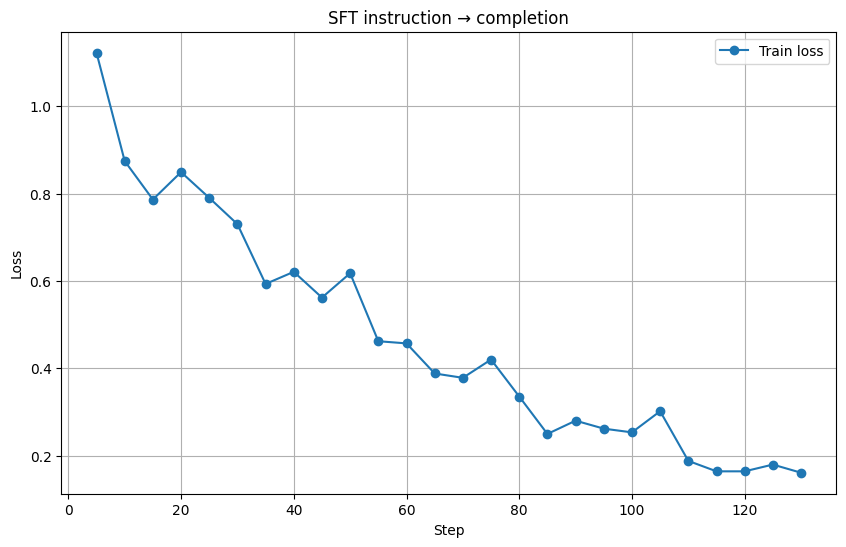

In [10]:
import matplotlib.pyplot as plt

history = trainer.state.log_history
train_points = [
    (record.get("step"), record["loss"])
    for record in history
    if "loss" in record and "eval_loss" not in record
]

plt.figure(figsize=(10, 6))
if train_points:
    plt.plot(
        [point[0] for point in train_points],
        [point[1] for point in train_points],
        marker="o",
        label="Train loss",
    )
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("SFT instruction → completion")
plt.grid(True)
plt.legend()
plt.show()


## 11. Menyimpan adapter dan merged model


In [11]:
model.save_pretrained(str(ADAPTER_DIR))
tokenizer.save_pretrained(str(ADAPTER_DIR))
print("LoRA adapter disimpan di:", ADAPTER_DIR)

if SAVE_MERGED_16BIT:
    model.save_pretrained_merged(
        str(MERGED_DIR),
        tokenizer,
        save_method="merged_16bit",
    )
    print("Merged model 16-bit disimpan di:", MERGED_DIR)
else:
    print(
        "Merged model tidak dibuat karena SAVE_MERGED_16BIT=False. "
        "Ubah menjadi True lalu jalankan ulang cell ini bila API membutuhkan merged model."
    )


Unsloth: Restored added_tokens_decoder metadata in /workspace/model/sft_instruction_completion/lora_adapter/tokenizer_config.json.


LoRA adapter disimpan di: /workspace/model/sft_instruction_completion/lora_adapter
Merged model tidak dibuat karena SAVE_MERGED_16BIT=False. Ubah menjadi True lalu jalankan ulang cell ini bila API membutuhkan merged model.


## 12. Fungsi inference tanpa retrieval

Fungsi ini hanya mengirim pertanyaan ke model hasil fine-tuning. Tidak ada `sources`, dokumen, atau konteks tambahan.


In [12]:
FastLanguageModel.for_inference(model)


def generate_answer(question, max_new_tokens=MAX_NEW_TOKENS):
    question = str(question).strip()
    if not question:
        raise ValueError("Pertanyaan tidak boleh kosong.")

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": question},
    ]

    prompt_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer(
        prompt_text,
        return_tensors="pt",
        add_special_tokens=False,
    ).to(model.device)

    with torch.inference_mode():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            repetition_penalty=1.05,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
        )

    generated_tokens = outputs[0, inputs["input_ids"].shape[1]:]
    answer = tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True,
    ).strip()

    return answer


print("Fungsi generate_answer siap.")


Fungsi generate_answer siap.


## 13. Uji pertanyaan yang ada di dataset


In [13]:
# Mengambil contoh pertama dari dataset. Ganti TEST_QUESTION sesuai kebutuhan.
TEST_QUESTION = training_rows[0]["instruction"]
EXPECTED_COMPLETION = training_rows[0]["completion"]

prediction = generate_answer(TEST_QUESTION)

print("PERTANYAAN:")
print(TEST_QUESTION)
print("\nEXPECTED COMPLETION:")
print(EXPECTED_COMPLETION)
print("\nHASIL MODEL:")
print(prediction)


Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/workspace/.venv/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/workspace/.venv/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


PERTANYAAN:
Apa sih arti pemerintahan desa itu ?

EXPECTED COMPLETION:
Pemerintahan desa adalah penyelenggaraan urusan pemerintahan oleh pemerintah desa dan badan permusyawaratan desa dalam mengatur dan mengurus kepentingan masyarakat setempat berdasarkan asal-usul dan adat istiadat setempat yang diakui dan dihormati dalam sistem pemerintahan negara kesatuan republik indonesia.

HASIL MODEL:
Pemerintahan desa adalah penyelenggaraan urusan pemerintahan oleh pemerintah desa dan badan permusyawaratan desa dalam mengatur dan mengurus kepentingan masyarakat setempat berdasarkan asal-usul dan adat istiadat setempat yang diakui dan dihormati dalam sistem pemerintahan negara kesatuan republik indonesia.


## 14. Uji contoh BPD


In [14]:
question_bpd = "BPD itu apa sih, fungsinya buat apa di desa?"
print(generate_answer(question_bpd))


Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


BPD, atau Badan Permusyawaratan Desa, adalah lembaga yang melaksanakan fungsi pemerintahan di desa. Anggotanya merupakan wakil dari penduduk desa yang ditetapkan secara demokratis. Fungsinya meliputi menampung dan menyalurkan aspirasi masyarakat serta melakukan pengawasan terhadap penyelenggaraan pemerintah desa.


## 15. Bentuk inference yang perlu digunakan pada API

API harus memakai pola prompt yang sama seperti fungsi `generate_answer()`:

```text
system prompt
+ pertanyaan user
→ model.generate()
→ jawaban
```

Jangan tambahkan:

- hasil retrieval;
- daftar `sources` ke dalam prompt;
- dokumen referensi;
- instruksi memilih/menolak konteks;
- format `KONTEKS_DIPILIH`, `KONTEKS_DITOLAK`, atau `BUKTI`.

Contoh respons API sederhana:

```json
{
  "status": "success",
  "message": "Jawaban berhasil diproses",
  "answer": "..."
}
```

Apabila API memuat merged model, ubah `SAVE_MERGED_16BIT=True`, jalankan cell penyimpanan, arahkan API ke folder `merged_16bit`, lalu restart proses API agar model lama tidak tetap berada di memori.
